In [1]:
!pip install gym-chess python-chess numpy==1.23.5 imageio pillow cairosvg

import gym
import gym_chess
import chess
import chess.svg
import numpy as np
from typing import List, Tuple
import time
from IPython.display import display, clear_output, SVG
from gym_chess.alphazero import BoardEncoding, MoveEncoding
import imageio
from PIL import Image
import io
import os
import cairosvg

In [10]:
class ChessMinimaxAgent:
    def __init__(self, depth=3, use_alphazero_encoding=False, env=None):
        self.depth = depth
        self.node_count = 0
        self.use_alphazero_encoding = use_alphazero_encoding
        if use_alphazero_encoding and env:
            self.move_encoder = MoveEncoding(env)  # Pass env to MoveEncoding

    def evaluate_board(self, board: chess.Board) -> float:
        """Evaluation function using piece-square tables"""
        if board.is_checkmate():
            return float('inf') if board.turn == chess.BLACK else float('-inf')
        if board.is_game_over():
            return 0

        # Piece values with piece-square tables
        piece_values = {
            chess.PAWN: (1, self._pawn_table),
            chess.KNIGHT: (3, self._knight_table),
            chess.BISHOP: (3, self._bishop_table),
            chess.ROOK: (5, self._rook_table),
            chess.QUEEN: (9, self._queen_table),
            chess.KING: (0, self._king_table)
        }

        score = 0

        # Evaluate material and piece-square values
        for square in chess.SQUARES:
            piece = board.piece_at(square)
            if piece:
                value, table = piece_values[piece.piece_type]
                score += value * (1 if piece.color == chess.WHITE else -1)

                # Add piece-square table value
                table_value = table[square] if piece.color == chess.WHITE else table[chess.square_mirror(square)]
                score += table_value * 0.1  # Scale down positional values

        # Add mobility bonus
        mobility = len(list(board.legal_moves))
        if board.turn == chess.WHITE:
            score += mobility * 0.01
        else:
            score -= mobility * 0.01

        return score


       # Piece-square tables
    _pawn_table = np.array([
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 5, 10, 10,-20,-20, 10, 10,  5],
        [ 5, -5,-10,  0,  0,-10, -5,  5],
        [ 0,  0,  0, 20, 20,  0,  0,  0],
        [ 5,  5, 10, 25, 25, 10,  5,  5],
        [10, 10, 20, 30, 30, 20, 10, 10],
        [50, 50, 50, 50, 50, 50, 50, 50],
        [ 0,  0,  0,  0,  0,  0,  0,  0]
    ]).flatten()

    _knight_table = np.array([
        [-50,-40,-30,-30,-30,-30,-40,-50],
        [-40,-20,  0,  5,  5,  0,-20,-40],
        [-30,  5, 10, 15, 15, 10,  5,-30],
        [-30,  0, 15, 20, 20, 15,  0,-30],
        [-30,  5, 15, 20, 20, 15,  5,-30],
        [-30,  0, 10, 15, 15, 10,  0,-30],
        [-40,-20,  0,  0,  0,  0,-20,-40],
        [-50,-40,-30,-30,-30,-30,-40,-50]
    ]).flatten()

    _bishop_table = np.array([
        [-20,-10,-10,-10,-10,-10,-10,-20],
        [-10,  5,  0,  0,  0,  0,  5,-10],
        [-10, 10, 10, 10, 10, 10, 10,-10],
        [-10,  0, 10, 10, 10, 10,  0,-10],
        [-10,  5,  5, 10, 10,  5,  5,-10],
        [-10,  0,  5, 10, 10,  5,  0,-10],
        [-10,  0,  0,  0,  0,  0,  0,-10],
        [-20,-10,-10,-10,-10,-10,-10,-20]
    ]).flatten()

    _rook_table = np.array([
        [  0,  0,  0,  0,  0,  0,  0,  0],
        [  5, 10, 10, 10, 10, 10, 10,  5],
        [ -5,  0,  0,  0,  0,  0,  0, -5],
        [ -5,  0,  0,  0,  0,  0,  0, -5],
        [ -5,  0,  0,  0,  0,  0,  0, -5],
        [ -5,  0,  0,  0,  0,  0,  0, -5],
        [ -5,  0,  0,  0,  0,  0,  0, -5],
        [  0,  0,  0,  5,  5,  0,  0,  0]
    ]).flatten()

    _queen_table = np.array([
        [-20,-10,-10, -5, -5,-10,-10,-20],
        [-10,  0,  0,  0,  0,  0,  0,-10],
        [-10,  0,  5,  5,  5,  5,  0,-10],
        [ -5,  0,  5,  5,  5,  5,  0, -5],
        [  0,  0,  5,  5,  5,  5,  0, -5],
        [-10,  5,  5,  5,  5,  5,  0,-10],
        [-10,  0,  5,  0,  0,  0,  0,-10],
        [-20,-10,-10, -5, -5,-10,-10,-20]
    ]).flatten()

    _king_table = np.array([
        [-30,-40,-40,-50,-50,-40,-40,-30],
        [-30,-40,-40,-50,-50,-40,-40,-30],
        [-30,-40,-40,-50,-50,-40,-40,-30],
        [-30,-40,-40,-50,-50,-40,-40,-30],
        [-20,-30,-30,-40,-40,-30,-30,-20],
        [-10,-20,-20,-20,-20,-20,-20,-10],
        [ 20, 20,  0,  0,  0,  0, 20, 20],
        [ 20, 30, 10,  0,  0, 10, 30, 20]
    ]).flatten()

    def reset_node_count(self):
        self.node_count = 0

    def minimax(self, board: chess.Board, depth: int, maximizing_player: bool) -> Tuple[float, chess.Move]:
        self.node_count += 1

        if depth == 0 or board.is_game_over():
            return self.evaluate_board(board), None

        legal_moves = list(board.legal_moves)
        if not legal_moves:
            return self.evaluate_board(board), None

        best_move = legal_moves[0]

        if maximizing_player:
            max_eval = float('-inf')
            for move in legal_moves:
                board.push(move)
                eval, _ = self.minimax(board, depth-1, False)
                board.pop()
                if eval > max_eval:
                    max_eval = eval
                    best_move = move
            return max_eval, best_move
        else:
            min_eval = float('inf')
            for move in legal_moves:
                board.push(move)
                eval, _ = self.minimax(board, depth-1, True)
                board.pop()
                if eval < min_eval:
                    min_eval = eval
                    best_move = move
            return min_eval, best_move


def display_board(board, last_move=None):
    """Display the chess board using SVG"""
    svg = chess.svg.board(
        board=board,
        lastmove=last_move,
        size=400
    )
    display(SVG(svg))
    return svg

def play_minimax_game(depth=3, use_alphazero_encoding=False, save_video=False, video_filename="chess_game.mp4"):
    """Play a full game using gym-chess environment with proper encoding"""
    # Set up video recording
    if save_video:
        frames = []
        os.makedirs("videos", exist_ok=True)

    # Set up environment
    env = gym.make('Chess-v0')
    if use_alphazero_encoding:
        env = BoardEncoding(env, history_length=1)

    agent = ChessMinimaxAgent(depth, use_alphazero_encoding, env)
    observation = env.reset()
    board = env.unwrapped._board
    last_move = None
    move_count = 0

    while True:
        # Display current state
        clear_output(wait=True)
        print(f"Move {move_count + 1}: {'White' if board.turn == chess.WHITE else 'Black'} to move")
        svg_data = display_board(board, last_move)

        # Capture frame for video
        if save_video:
            try:
                png_data = cairosvg.svg2png(bytestring=svg_data.encode('utf-8'))
                img = Image.open(io.BytesIO(png_data))
                frames.append(np.array(img))
            except Exception as e:
                print(f"Error capturing frame: {e}")

        # Check game termination conditions
        if board.is_game_over():
            break

        if not any(board.legal_moves):
            print("No legal moves available - game over")
            break

        # Get and validate move
        _, move = agent.minimax(board, agent.depth, board.turn == chess.WHITE)

        # Handle case where minimax returns None for move
        if move is None:
            print("Warning: Minimax returned None move, selecting random legal move")
            move = random.choice(list(board.legal_moves))
        elif move not in board.legal_moves:
            print(f"Warning: Attempted illegal move {move.uci()} - choosing random legal move")
            move = random.choice(list(board.legal_moves))

        print(f"Playing: {move.uci()}")
        observation, reward, done, info = env.step(move)
        last_move = move
        move_count += 1

        # Small delay for visualization
        time.sleep(0.5)

    # Game over - display final state and reason
    clear_output(wait=True)
    print("Final board after", move_count, "moves:")
    final_svg = display_board(board, last_move)

    # Detailed termination analysis
    if board.is_checkmate():
        winner = "White" if board.turn == chess.BLACK else "Black"
        print(f"{winner} wins by checkmate!")
    elif board.is_stalemate():
        print("Game ended in stalemate")
    elif board.is_insufficient_material():
        print("Draw by insufficient material")
    elif board.is_seventyfive_moves():
        print("Draw by 75-move rule")
    elif board.is_fivefold_repetition():
        print("Draw by fivefold repetition")
    elif board.can_claim_draw():
        print("Draw by claimable condition")
    else:
        print("Game ended for unknown reason")
    print("Official result:", board.result(claim_draw=True))

    # Save video if recording was enabled
    if save_video and frames:
        try:
            # Add final frame multiple times
            final_img = Image.open(io.BytesIO(cairosvg.svg2png(bytestring=final_svg.encode('utf-8'))))
            for _ in range(10):
                frames.append(np.array(final_img))

            video_path = f"videos/{video_filename}"
            imageio.mimsave(video_path, frames, fps=2)
            print(f"Game video saved to: {video_path}")
        except Exception as e:
            print(f"Error saving video: {e}")

    env.close()



Final board after 298 moves:


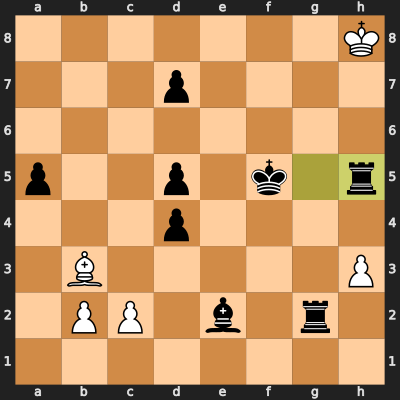

Black wins by checkmate!
Official result: 0-1
Game video saved to: videos/standard_chess.mp4


In [11]:
# Play and record a game with standard chess moves
print("Playing with standard chess moves:")
play_minimax_game(depth=3, use_alphazero_encoding=False, save_video=True, video_filename="standard_chess.mp4")

Final board after 298 moves:


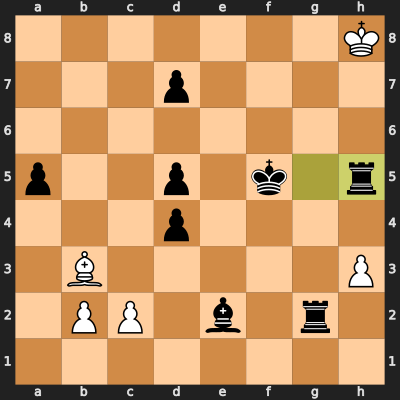

Black wins by checkmate!
Official result: 0-1
Game video saved to: videos/alphazero_chess.mp4


In [12]:
# Play and record a game with AlphaZero encoding
print("\nPlaying with AlphaZero encoding:")
play_minimax_game(depth=3, use_alphazero_encoding=True, save_video=True, video_filename="alphazero_chess.mp4")

With plots


In [7]:
import matplotlib.pyplot as plt

depths = list(range(1, 6))  # Vary depth from 1 to 5
times = []
nodes = []

env = gym.make('Chess-v0')

for depth in depths:
    agent = ChessMinimaxAgent(depth=depth, use_alphazero_encoding=False, env=env)
    board = chess.Board()
    agent.reset_node_count()

    start = time.time()
    _, move = agent.minimax(board.copy(), depth, maximizing_player=True)
    end = time.time()

    times.append(end - start)
    nodes.append(agent.node_count)

    print(f"Depth: {depth}, Time: {end - start:.4f}s, Nodes Evaluated: {agent.node_count}")


Depth: 1, Time: 0.0055s, Nodes Evaluated: 21
Depth: 2, Time: 0.0940s, Nodes Evaluated: 421
Depth: 3, Time: 2.5543s, Nodes Evaluated: 9323
Depth: 4, Time: 43.4698s, Nodes Evaluated: 206604
Depth: 5, Time: 1069.9050s, Nodes Evaluated: 5072213


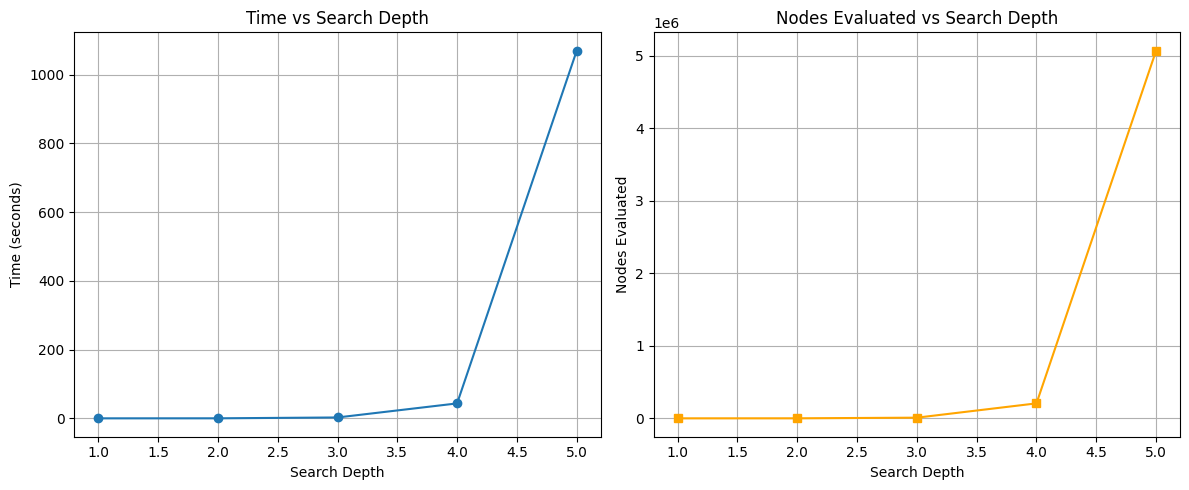

In [8]:
plt.figure(figsize=(12, 5))

# Time vs Depth
plt.subplot(1, 2, 1)
plt.plot(depths, times, marker='o')
plt.title("Time vs Search Depth")
plt.xlabel("Search Depth")
plt.ylabel("Time (seconds)")
plt.grid(True)

# Nodes vs Depth
plt.subplot(1, 2, 2)
plt.plot(depths, nodes, marker='s', color='orange')
plt.title("Nodes Evaluated vs Search Depth")
plt.xlabel("Search Depth")
plt.ylabel("Nodes Evaluated")
plt.grid(True)

plt.tight_layout()
plt.show()
